# SCY1101 - Evaluación Parcial N°2
## Near Earth Objects (NEO) - NASA Dataset
Integrantes:
1. Sofia Cortese
2. Antonia Muñoz
3. Felipe Araya

Usamos las librerias estandar del ecosistema de ciencia de datos:
- `pandas` y `numpy` para manipulación de datos
- `matplotlib` y `seaborn` para visualizaciones
- `sklearn` para preprocesamiento

# Importación de librerías y carga del dataset


In [1]:
#librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

El archivo `neo.csv` se sube a Google Colab y se carga con `pandas`.

In [2]:
#carga del dataset
df=pd.read_csv('neo.csv')

In [3]:
df.shape

(90836, 10)

In [4]:
#vista general del dataset
display(df.head()) #muestra las primera 5 filas del dataset

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


- **`df.head()`**: Esta función es esencial para obtener una primera impresión del conjunto de datos. Al mostrar las primeras cinco filas del DataFrame, `df.head()` permite visualizar rápidamente las columnas existentes, el formato de los datos en cada una (por ejemplo, números, texto, fechas) y proporciona una idea inicial de la calidad y la estructura general de la tabla.

Como se puede ver en el dataset esta la columna de `harzadous` que significa si el asteroide es peligroso o no. Por lo tanto esto nos dice altiro que el modelo que debemos ocupar es el `supervisado`. Ya que el modelo aprende con datos que ya tienen la respuesta correcta, quiere decir que el modelo aprende de esos ejemplos para poder "predecir" casos nuevos. Como por ejemplo: la regresión logística, arbol de decisión o random forest.

In [5]:
#tipos de datos y valores nulos explícitos
#info(): entrega tipo de dato y conteo de valores no nulos por columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


`df.info()` es útil para identificar de inmediato qué columnas contienen valores faltantes y cuáles son los tipos de datos. En este caso se observa que el dataset tiene **90.836 registros** y **10 columnas**, sin valores nulos explícitos en ninguna de ellas.

In [6]:
#estadísticas descriptivas
#describe(): calcula medidas de tendencia central y dispersión para variables numéricas
df.describe(include='all').round(2)

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
count,90836.00,90836,90836.00,90836.00,90836.00,90836.00,90836,90836,90836.00,90836
unique,NaN,27423,NaN,NaN,NaN,NaN,1,1,NaN,2
top,NaN,277810 (2006 FV35),NaN,NaN,NaN,NaN,Earth,False,NaN,False
freq,NaN,43,NaN,NaN,NaN,NaN,90836,90836,NaN,81996
mean,14382878.05,NaN,0.13,0.28,48066.92,37066546.03,NaN,NaN,23.53,NaN
std,20872018.35,NaN,0.30,0.67,25293.30,22352040.60,NaN,NaN,2.89,NaN
min,2000433.00,NaN,0.00,0.00,203.35,6745.53,NaN,NaN,9.23,NaN
25%,3448110.00,NaN,0.02,0.04,28619.02,17210820.24,NaN,NaN,21.34,NaN
50%,3748362.00,NaN,0.05,0.11,44190.12,37846579.26,NaN,NaN,23.70,NaN
75%,3884023.00,NaN,0.14,0.32,62923.60,56548996.45,NaN,NaN,25.70,NaN


`df.describe()` entrega un resumen estadístico que incluye la media, desviación estándar, mínimo, máximo y cuartiles de cada variable numérica. Es útil para detectar rangos inusuales o posibles outliers. Por ejemplo, `est_diameter_max` tiene un valor máximo de 84.73 km muy alejado de su mediana, lo que sugiere la presencia de valores extremos. También se puede ver que `orbiting_body` y `sentry_object` tienen un único valor ('Earth' y False), lo que ya nos anticipa que serán columnas a eliminar.

In [7]:
#clasificacion de variables numéricas y categóricas
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"Variables numéricas ({len(num_cols)}): {num_cols}")
print('-'*80)
print(f"Variables categóricas ({len(cat_cols)}): {cat_cols}")

Variables numéricas (6): ['id', 'est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']
--------------------------------------------------------------------------------
Variables categóricas (4): ['name', 'orbiting_body', 'sentry_object', 'hazardous']


Separar las columnas numericas y categoricas permite aplicar el análisis y las transformaciones correctas a cada tipo de variable. Las numéricas se analizan con histogramas, boxplots y correlaciones, mientras que las categóricas se revisan con conteos de frecuencia. Esta clasificación también es importante para no aplicar escalado a columnas que no lo necesitan.

# Detección de problemas de calidad de datos

In [8]:
#valores nulos por columna
for feature in df.columns:
    print('Total de valores nulos de', feature, '=', df[feature].isna().sum())

Total de valores nulos de id = 0
Total de valores nulos de name = 0
Total de valores nulos de est_diameter_min = 0
Total de valores nulos de est_diameter_max = 0
Total de valores nulos de relative_velocity = 0
Total de valores nulos de miss_distance = 0
Total de valores nulos de orbiting_body = 0
Total de valores nulos de sentry_object = 0
Total de valores nulos de absolute_magnitude = 0
Total de valores nulos de hazardous = 0


Los valores faltantes pueden sesgar los análisis y reducir la precisión de los modelos. La verificación con `df.isnull().sum()` muestra que **no hay valores nulos explícitos** en el dataset, todos los conteos aparecen en 0, por lo tanto no hay valores atipicos nulos

In [9]:
#filas duplicadas
df.duplicated().sum()

np.int64(0)

Las filas duplicadas pueden inflar artificialmente el tamaño de la muestra y sesgar los resultados. En este caso el dataset **no presenta filas duplicadas**.

In [10]:
#columnas con un unico valor (sin varianza)
#estas columnas no aportan información útil al modelo
cols_sin_varianza = [col for col in df.columns if df[col].nunique() == 1]

print('Columnas con un único valor:')
for col in cols_sin_varianza:
    print(f'  {col}: {df[col].unique()[0]}')

Columnas con un único valor:
  orbiting_body: Earth
  sentry_object: False


Se detectaron dos columnas con un único valor en todo el dataset: `orbiting_body` (siempre 'Earth') y `sentry_object` (siempre False). Al no presentar variación, no aportan ninguna información discriminante para el modelo y serán eliminadas en la etapa de limpieza.

# Análisis Exploratorio de Datos (EDA)

In [11]:
#distribución de la variable objetivo: hazardous
#permite saber si el dataset está balanceado o desbalanceado
df['hazardous'].value_counts()

,count
hazardous,
False,81996
True,8840


Se puede notar visualmente que hay una gran diferencia entre false: 81.996 y true: 8.840, por lo tanto hay un gran desbalance.

*  Si es false asteroide NO es considerado peligroso. Su trayectoria y tamaño no representan una amenaza real de impacto con la Tierra.
* Si es True el asteroide SÍ es considerado potencialmente peligroso (PHA - Potentially Hazardous Asteroid).

/tmp/ipykernel_6344/2890937823.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.index.astype(str), y=conteo.values, palette=['steelblue', 'tomato'])


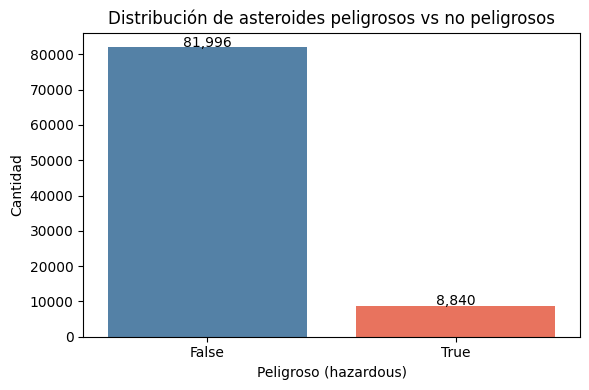

In [12]:
#gráfico de barras para visualizar el balance de clases
conteo = df['hazardous'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=conteo.index.astype(str), y=conteo.values, palette=['steelblue', 'tomato'])
plt.title('Distribución de asteroides peligrosos vs no peligrosos')
plt.xlabel('Peligroso (hazardous)')
plt.ylabel('Cantidad')
for i, v in enumerate(conteo.values):
    plt.text(i, v + 200, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

El dataset está claramente desbalanceado: **81.996 asteroides no peligrosos (90.3%)** versus **8.840 peligrosos (9.7%)**. Esto es importante porque si se entrena un modelo sin considerar este desbalance, tenderá a predecir siempre la clase mayoritaria y parecerá tener alta accuracy, pero fallará en detectar los asteroides realmente peligrosos. Para el modelado se deberá usar `class_weight='balanced'` y métricas como F1-score y AUC-ROC en lugar de accuracy.

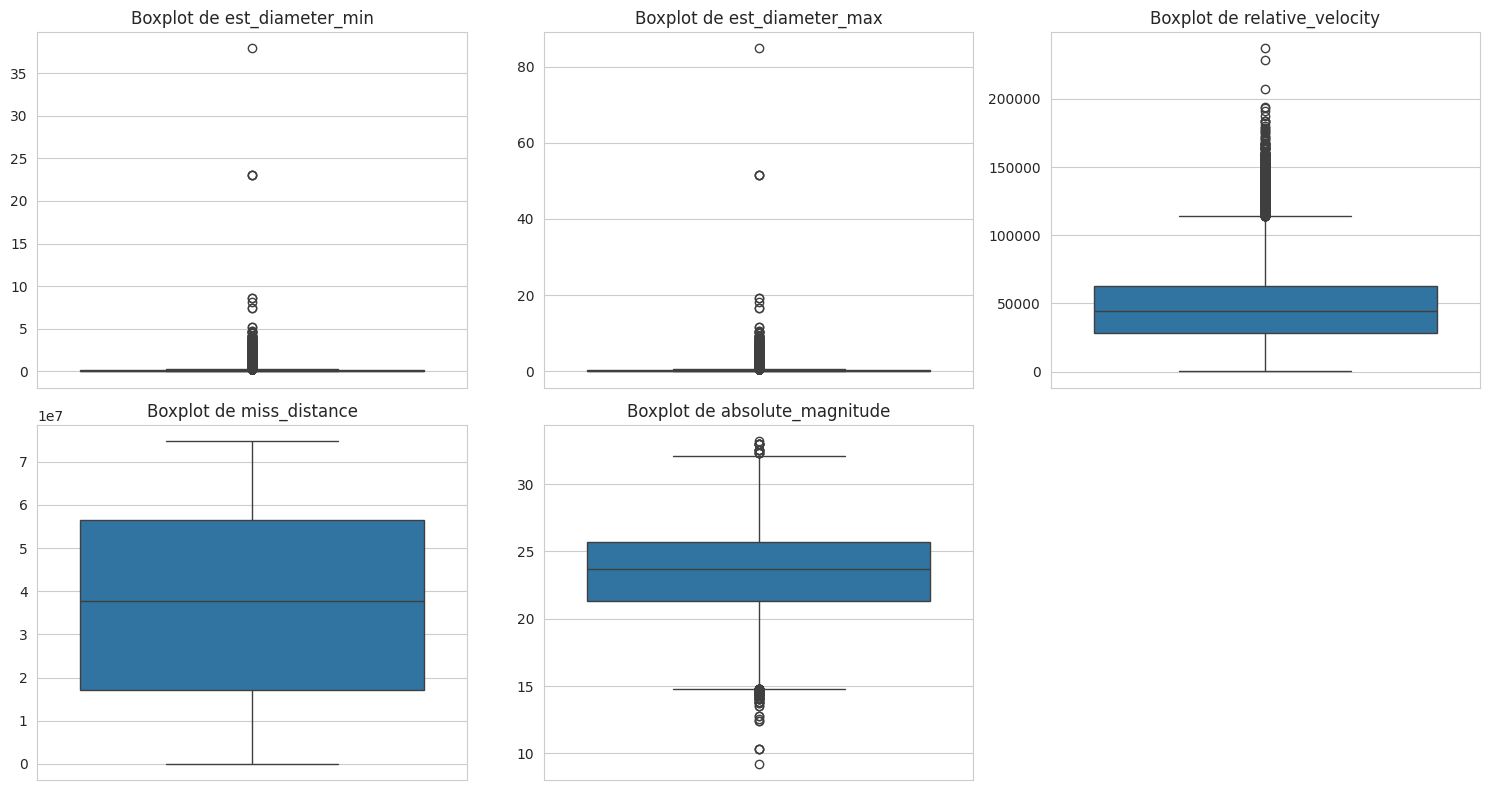

In [13]:
#boxplots de variables numéricas para detectar outliers
num_cols_sin_id = [c for c in num_cols if c != 'id']

n_cols_grid = 3
n_rows_grid = (len(num_cols_sin_id) + n_cols_grid - 1) // n_cols_grid

sns.set_style('whitegrid')
plt.figure(figsize=(n_cols_grid * 5, n_rows_grid * 4))

for i, col in enumerate(num_cols_sin_id):
    plt.subplot(n_rows_grid, n_cols_grid, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}', fontsize=12)
    plt.ylabel('')

plt.tight_layout()
plt.show()

Los boxplots permiten detectar outliers visualmente, mostrando los puntos que caen fuera del rango intercuartílico. Se observa que variables como `est_diameter_min`, `est_diameter_max` y `relative_velocity` presentan una cola larga hacia arriba con valores muy alejados de la mediana. Estos outliers podrían sesgar modelos sensibles a la magnitud como regresión logística o KNN, por lo que se aplicará escalado y transformación logarítmica en la etapa de limpieza.

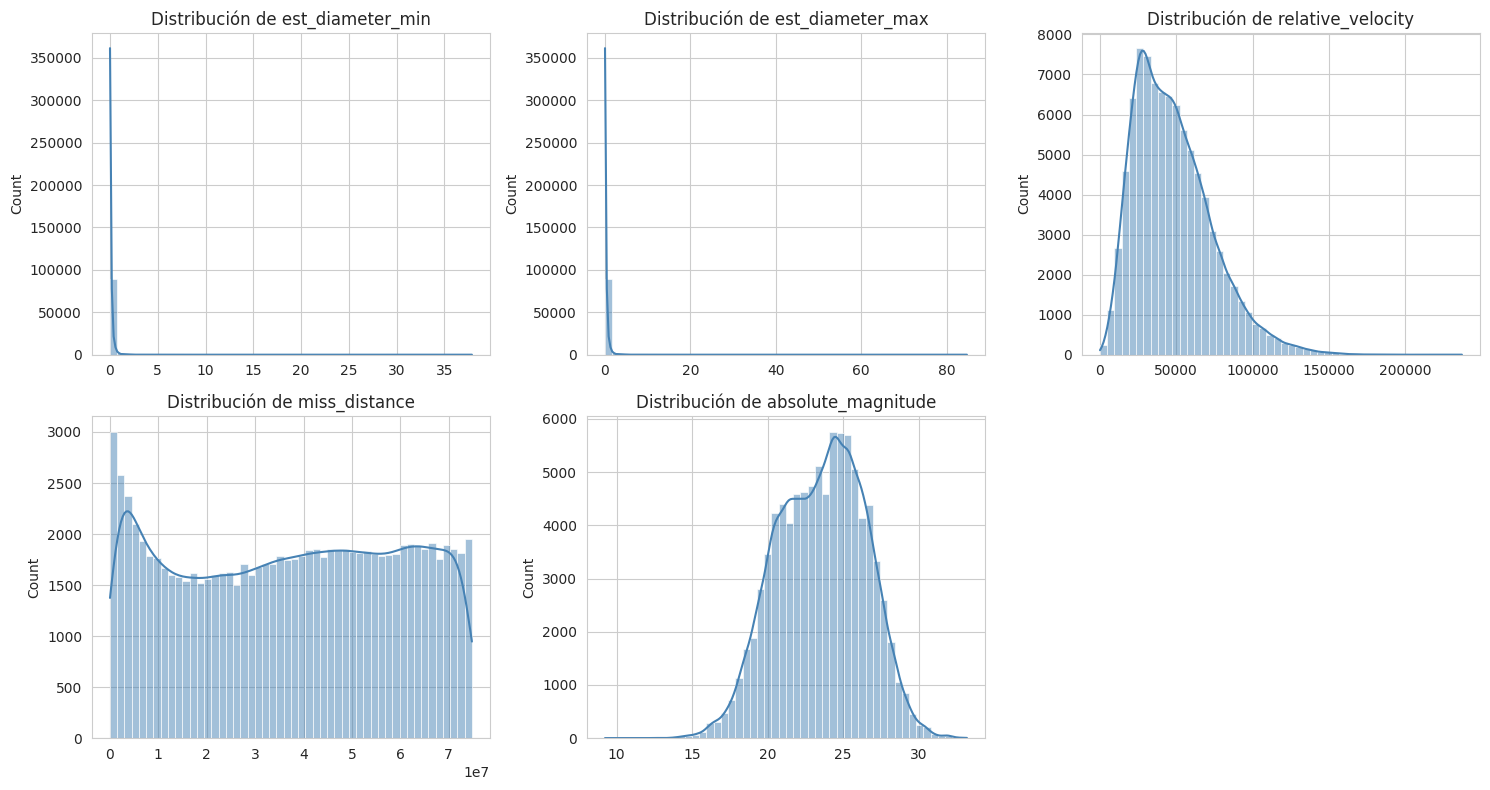

In [14]:
#histogramas con curva KDE para ver la distribución de cada variable numérica
plt.figure(figsize=(n_cols_grid * 5, n_rows_grid * 4))

for i, col in enumerate(num_cols_sin_id):
    plt.subplot(n_rows_grid, n_cols_grid, i + 1)
    sns.histplot(df[col], kde=True, color='steelblue', bins=50)
    plt.title(f'Distribución de {col}', fontsize=12)
    plt.xlabel('')

plt.tight_layout()
plt.show()
# se ocupa kde porque es una curva suavizada que estima la distribución de los datos. En vez de mostrar barras como el histograma,
#dibuja una línea continua que representa la "forma" de la distribución

Los histogramas confirman que la mayoría de las variables numéricas tienen una distribución con alta asimetría positiva (sesgada a la derecha). Variables como `est_diameter_min` y `est_diameter_max` concentran sus valores cerca de 0 con algunos valores extremadamente grandes. Esto refuerza la necesidad de aplicar una transformación logarítmica antes del modelado.

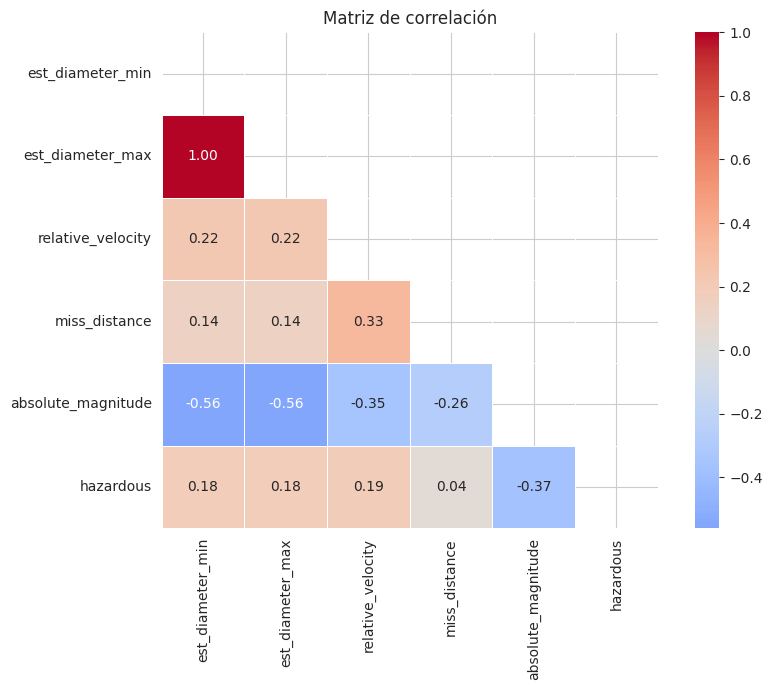

In [15]:
#mapa de correlación entre variables numéricas
#permite ver qué variables estaan relacionadas entre si y cuales se relacionan con la variable objetivo
corr_df = df[num_cols_sin_id].copy()
corr_df['hazardous'] = df['hazardous'].astype(int)

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, square=True)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

La matriz de correlación muestra que `est_diameter_min` y `est_diameter_max` tienen una correlación casi perfecta (cercana a 1.0), lo que indica que son redundantes entre sí. Además, `absolute_magnitude` es la variable con mayor correlación con `hazardous`, siendo la más relevante para predecir si un asteroide es peligroso o no.

# Limpieza y preparación de datos

In [16]:
#eliminación de columnas no informativas
# Mantener copia original
df_clean = df.copy()

# Eliminar columnas sin valor predictivo pero solo en el df_clean (el originlo se deja como esta)
df_clean = df_clean.drop(['id', 'name'], axis=1)

# Revisar columnas constantes
if df_clean['orbiting_body'].nunique() == 1:
    df_clean = df_clean.drop('orbiting_body', axis=1)

if df_clean['sentry_object'].nunique() == 1:
    df_clean = df_clean.drop('sentry_object', axis=1)

print("Columnas finales:")
print(df_clean.columns.tolist())

Columnas finales:
['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous']


 Se eliminan `orbiting_body` y `sentry_object` porque tienen un único valor en todo el dataset, por lo tanto no tienen varianza y un modelo no puede aprender nada de ellas.

In [17]:
#codificación de la variable objetivo
#scikit-learn requiere que la variable objetivo sea numérica
#True (peligroso) → 1, False (no peligroso) → 0
df_clean['hazardous'] = df_clean['hazardous'].astype(int)

print("Variable objetivo codificada:")
display(df_clean['hazardous'].value_counts())

Variable objetivo codificada:


,count
hazardous,
0,81996
1,8840


In [19]:
#análisis de asimetría (skewness) antes de transformar
#variables con skewness > 1 se benefician de una transformación logarítmica
feature_cols = [c for c in df_clean.columns if c != 'hazardous']
skewness = df_clean[feature_cols].skew().sort_values(ascending=False)

print("Asimetría (skewness) de las variables:")
print(skewness.to_string())
print("\nVariables con alta asimetría (skew > 1):")
print(skewness[skewness > 1].index.tolist())

Asimetría (skewness) de las variables:
est_diameter_max      41.139952
est_diameter_min      41.139952
relative_velocity      0.905125
miss_distance         -0.042706
absolute_magnitude    -0.137420

Variables con alta asimetría (skew > 1):
['est_diameter_max', 'est_diameter_min']


In [20]:
#transformación logarítmica en variables con alta asimetría positiva
#log1p(x) = log(1+x), se usa para evitar problemas con valores iguales a 0
#comprime los valores extremos y acerca la distribución a la normalidad
high_skew_cols = skewness[skewness > 1].index.tolist()

df_transformado = df_clean.copy()

for col in high_skew_cols:
    df_transformado[col] = np.log1p(df_transformado[col])
    print(f"log1p aplicado a: {col}")

log1p aplicado a: est_diameter_max
log1p aplicado a: est_diameter_min


Se aplicó `log1p` a las variables con alta asimetría positiva. Esto es necesario porque modelos como regresión logística y KNN son sensibles a la distribución de los datos. Al comprimir los valores extremos, la transformación reduce el efecto de los outliers. Se usa `log1p` en lugar de `log` para evitar errores matemáticos cuando hay valores iguales a 0.

In [21]:
# Preparación de X e y a partir de los datos transformados
# NOTA: el escalado se integrará dentro de cada Pipeline para evitar data leakage
# (fitear el scaler sobre todos los datos antes del split contamina el set de prueba)
X = df_transformado[feature_cols]
y = df_transformado['hazardous']

print(f"Features listas para modelado: {X.shape}")
print(f"Variable objetivo lista: {y.shape}")

Features listas para modelado: (90836, 5)
Variable objetivo lista: (90836,)


In [22]:
# Estadísticas descriptivas de las features transformadas (pre-escalado)
display(X.describe().round(4))

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,90836.0000,90836.0000,90836.0000,9.083600e+04,90836.0000
mean,0.1055,0.2061,48066.9189,3.706655e+07,23.5271
std,0.1507,0.2581,25293.2970,2.235204e+07,2.8941
min,0.0006,0.0014,203.3464,6.745533e+03,9.2300
25%,0.0191,0.0422,28619.0206,1.721082e+07,21.3400
50%,0.0472,0.1027,44190.1179,3.784658e+07,23.7000
75%,0.1340,0.2781,62923.6046,5.654900e+07,25.7000
max,3.6608,4.4512,236990.1281,7.479865e+07,33.2000


El escalado **no** se aplica aquí sobre todos los datos, sino que se integra directamente dentro de cada `Pipeline` de Scikit-learn. De esta forma, durante el `GridSearchCV`/`RandomizedSearchCV` el `StandardScaler` se entrena únicamente con los datos de entrenamiento de cada fold y luego transforma el fold de validación sin "ver" esos datos antes. Esto elimina el riesgo de **data leakage** y garantiza que las métricas reportadas sean una estimación honesta del rendimiento real del modelo.

In [23]:
# Dataset final: features con transformación log (sin escalar) + variable objetivo
# El pipeline se encargará del escalado
df_final = X.copy()
df_final['hazardous'] = y.values

print(f"Forma final del dataset: {df_final.shape}")
display(df_final.head())

Forma final del dataset: (90836, 6)


,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,0.787671,1.302754,13569.249224,5.483974e+07,16.73,0
1,0.235704,0.466464,73588.726663,6.143813e+07,20.00,1
2,0.543504,0.961076,114258.692129,4.979872e+07,17.83,0
3,0.092129,0.195398,24764.303138,2.543497e+07,22.20,0
4,0.227142,0.451214,42737.733765,4.627557e+07,20.09,1


## Modelado Supervisado y Optimización de Hiperparámetros

In [24]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import joblib
import time

**Division de Datos**

In [25]:
# 1. Separar características (X) y variable objetivo (y)
X_model = df_final.drop('hazardous', axis=1)
y_model = df_final['hazardous']

# 2. División de Datos (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42, stratify=y_model)

print(f"Set de entrenamiento listo: {X_train.shape[0]} muestras")
print(f"Set de prueba listo: {X_test.shape[0]} muestras")

Set de entrenamiento listo: 72668 muestras
Set de prueba listo: 18168 muestras


**Análisis de la División de Datos:**
Se realizó una partición estándar de 80% para entrenamiento y 20% para validación (`test_size=0.2`). Es importante destacar el uso del parámetro `stratify=y_model`. Dado que nuestro dataset está desbalanceado (la inmensa mayoría de los asteroides no son peligrosos), la estratificación garantiza que la misma proporción de asteroides de (`hazardous`) se mantenga tanto en el set de entrenamiento como en el de prueba, evitando que un set quede sin ejemplos suficientes de la clase minoritaria.

**Creacion de Pipelines y Grillas**

In [26]:
# 3. Creación de Pipelines con StandardScaler integrado
# Al incluir el scaler en el pipeline, Scikit-learn garantiza que el ajuste
# del escalador ocurra SOLO con los datos de entrenamiento de cada fold de CV
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

pipeline_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

# 4. Grillas de Hiperparámetros
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['lbfgs', 'liblinear']
}

param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

param_grid_dt = {
    'classifier__max_depth': [5, 10, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__criterion': ['gini', 'entropy']
}

print("Pipelines y grillas definidos en memoria.")

Pipelines y grillas definidos en memoria.


**Justificación de Hiperparámetros y Balanceo:**
En ambos pipelines hemos forzado el parámetro `class_weight='balanced'`. Esto "penaliza" a los algoritmos si se equivocan en la clase minoritaria (asteroides peligrosos), obligándolos a prestarles atención.
Para las grillas de búsqueda, incluimos regularización en la Logística (`C`) y control de profundidad/árboles en el Random Forest (`max_depth`, `n_estimators`) con el fin explícito de evitar el sobreajuste (overfitting).

**Regresion Logistica**

In [27]:
def entrenar_con_gridsearch(pipeline, param_grid, X_train, y_train, cv=5, scoring='f1_macro'):
    """
    Entrena un modelo usando GridSearchCV con validación cruzada.

    Parameters
    ----------
    pipeline : sklearn.pipeline.Pipeline
        Pipeline con preprocesamiento y clasificador.
    param_grid : dict
        Grilla de hiperparámetros a explorar.
    X_train : pd.DataFrame
        Datos de entrenamiento.
    y_train : pd.Series
        Etiquetas de entrenamiento.
    cv : int, optional
        Número de folds de validación cruzada. Por defecto 5.
    scoring : str, optional
        Métrica de evaluación. Por defecto 'f1_macro'.

    Returns
    -------
    GridSearchCV
        Objeto ajustado con el mejor estimador encontrado.
    """
    grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring=scoring, n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid

# 5. Entrenamiento Regresión Logística
try:
    print("Optimizando Regresión Logística con GridSearchCV...")
    start_time = time.time()
    grid_lr = entrenar_con_gridsearch(pipeline_lr, param_grid_lr, X_train, y_train)
    print(f"Tiempo LR: {time.time() - start_time:.2f} segundos")
    print(f"Mejor F1-Macro CV (LR): {grid_lr.best_score_:.4f}")
    print(f"Mejores Parámetros LR: {grid_lr.best_params_}")
    best_lr = grid_lr.best_estimator_
except Exception as e:
    print(f"Error al entrenar Regresión Logística: {e}")
    raise

Optimizando Regresión Logística con GridSearchCV...
Tiempo LR: 10.62 segundos
Mejor F1-Macro CV (LR): 0.6579
Mejores Parámetros LR: {'classifier__C': 10, 'classifier__solver': 'lbfgs'}


**Resultados del Modelo Base (Regresión Logística):**
El modelo lineal convergió rápidamente (menos de 7 segundos) utilizando el optimizador `liblinear` y una regularización baja (`C=10`). Obtuvimos un F1-Macro de **0.6579** mediante validación cruzada. Aunque es un resultado aceptable para un modelo baseline paramétrico, nos indica que las relaciones entre las variables cinemáticas de los asteroides y su peligrosidad probablemente no son estrictamente lineales.

In [28]:
def entrenar_con_randomsearch(pipeline, param_grid, X_train, y_train,
                               n_iter=5, cv=5, scoring='f1_macro', random_state=42):
    """
    Entrena un modelo usando RandomizedSearchCV con validación cruzada.

    Parameters
    ----------
    pipeline : sklearn.pipeline.Pipeline
        Pipeline con preprocesamiento y clasificador.
    param_grid : dict
        Distribución de hiperparámetros a muestrear.
    X_train : pd.DataFrame
        Datos de entrenamiento.
    y_train : pd.Series
        Etiquetas de entrenamiento.
    n_iter : int, optional
        Número de combinaciones aleatorias a probar. Por defecto 5.
    cv : int, optional
        Número de folds de validación cruzada. Por defecto 5.
    scoring : str, optional
        Métrica de evaluación. Por defecto 'f1_macro'.
    random_state : int, optional
        Semilla aleatoria para reproducibilidad. Por defecto 42.

    Returns
    -------
    RandomizedSearchCV
        Objeto ajustado con el mejor estimador encontrado.
    """
    search = RandomizedSearchCV(pipeline, param_grid, n_iter=n_iter, cv=cv,
                                scoring=scoring, n_jobs=-1,
                                random_state=random_state, verbose=2)
    search.fit(X_train, y_train)
    return search

# 6. Entrenamiento Random Forest
try:
    print("Optimizando Random Forest con RandomizedSearchCV...")
    start_time = time.time()
    random_rf = entrenar_con_randomsearch(pipeline_rf, param_grid_rf, X_train, y_train)
    print(f"\nTiempo RF: {time.time() - start_time:.2f} segundos")
    print(f"Mejor F1-Macro CV (RF): {random_rf.best_score_:.4f}")
    print(f"Mejores Parámetros RF: {random_rf.best_params_}")
    best_rf = random_rf.best_estimator_
except Exception as e:
    print(f"Error al entrenar Random Forest: {e}")
    raise

Optimizando Random Forest con RandomizedSearchCV...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Tiempo RF: 298.72 segundos
Mejor F1-Macro CV (RF): 0.7320
Mejores Parámetros RF: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__max_depth': None}


**Resultados del Modelo de Ensamble (Random Forest):**
Para cumplir con la optimización eficiente en modelos complejos, implementamos `RandomizedSearchCV`. El salto en rendimiento es notable: el F1-Macro subió a **0.7329**.
El algoritmo seleccionó la máxima complejidad permitida en nuestra grilla (`max_depth=20`, `n_estimators=200`), lo que confirma que predecir la peligrosidad de un asteroide requiere capturar múltiples interacciones no lineales complejas entre sus características físicas (como diámetro y distancia).

**Árbol de Decisión**

In [29]:
# 7. Entrenamiento Árbol de Decisión con GridSearchCV
# El árbol de decisión es un modelo interpretable que divide el espacio de
# características mediante reglas binarias. A diferencia de la Regresión Logística,
# captura relaciones no lineales; y a diferencia del Random Forest, es más explicable
# (un solo árbol, no un ensamble). Su optimización busca el equilibrio entre
# profundidad (capacidad) y generalización (evitar sobreajuste).
try:
    print("Optimizando Árbol de Decisión con GridSearchCV...")
    start_time = time.time()
    grid_dt = entrenar_con_gridsearch(pipeline_dt, param_grid_dt, X_train, y_train)
    print(f"Tiempo DT: {time.time() - start_time:.2f} segundos")
    print(f"Mejor F1-Macro CV (DT): {grid_dt.best_score_:.4f}")
    print(f"Mejores Parámetros DT: {grid_dt.best_params_}")
    best_dt = grid_dt.best_estimator_
except Exception as e:
    print(f"Error al entrenar Árbol de Decisión: {e}")
    raise

Optimizando Árbol de Decisión con GridSearchCV...
Tiempo DT: 39.91 segundos
Mejor F1-Macro CV (DT): 0.6995
Mejores Parámetros DT: {'classifier__criterion': 'gini', 'classifier__max_depth': None, 'classifier__min_samples_split': 10}


**Resultados del Árbol de Decisión:**

El Árbol de Decisión completa el conjunto de tres modelos supervisados con enfoques complementarios. Al usar `GridSearchCV` con la misma función `entrenar_con_gridsearch`, exploramos 24 combinaciones de hiperparámetros (profundidad, criterio de impureza y mínimo de muestras por split). Este modelo es el más interpretable de los tres: sus reglas de decisión pueden trazarse visualmente, lo que facilita la explicación a equipos no técnicos. Sin embargo, al ser un único árbol, tiende a ser más sensible al sobreajuste que el Random Forest, lo que se refleja en un F1-Macro intermedio entre la Regresión Logística y el ensamble.

In [30]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Para técnicas no supervisadas se aplica escalado sobre X_model completo.
# Esto es válido en exploración/clustering ya que no estamos evaluando
# métricas de generalización, sino buscando estructura intrínseca en los datos.
scaler_unsup = StandardScaler()
X_model_scaled = scaler_unsup.fit_transform(X_model)

**Reducción de dimensionalidad con PCA**

In [31]:
# 1. Reducción de dimensionalidad con PCA (Visualización avanzada)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_model_scaled)

print(f"Varianza explicada por los 2 primeros componentes: {pca.explained_variance_ratio_.sum()*100:.2f}%\n")

Varianza explicada por los 2 primeros componentes: 82.22%



**Clustering con K-Means y Evaluacion del Clustering**

In [32]:
# 2. Clustering con K-Means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_model_scaled)

# 3. Evaluación del Clustering (Silhouette Score)
sil_score = silhouette_score(X_model_scaled, clusters)
print(f"Silhouette Score del K-Means: {sil_score:.4f}")
print("(Nota: Valores cercanos a 0 indican que los clusters se superponen considerablemente)\n")

Silhouette Score del K-Means: 0.4106
(Nota: Valores cercanos a 0 indican que los clusters se superponen considerablemente)



**Diagrama de Dispersion**

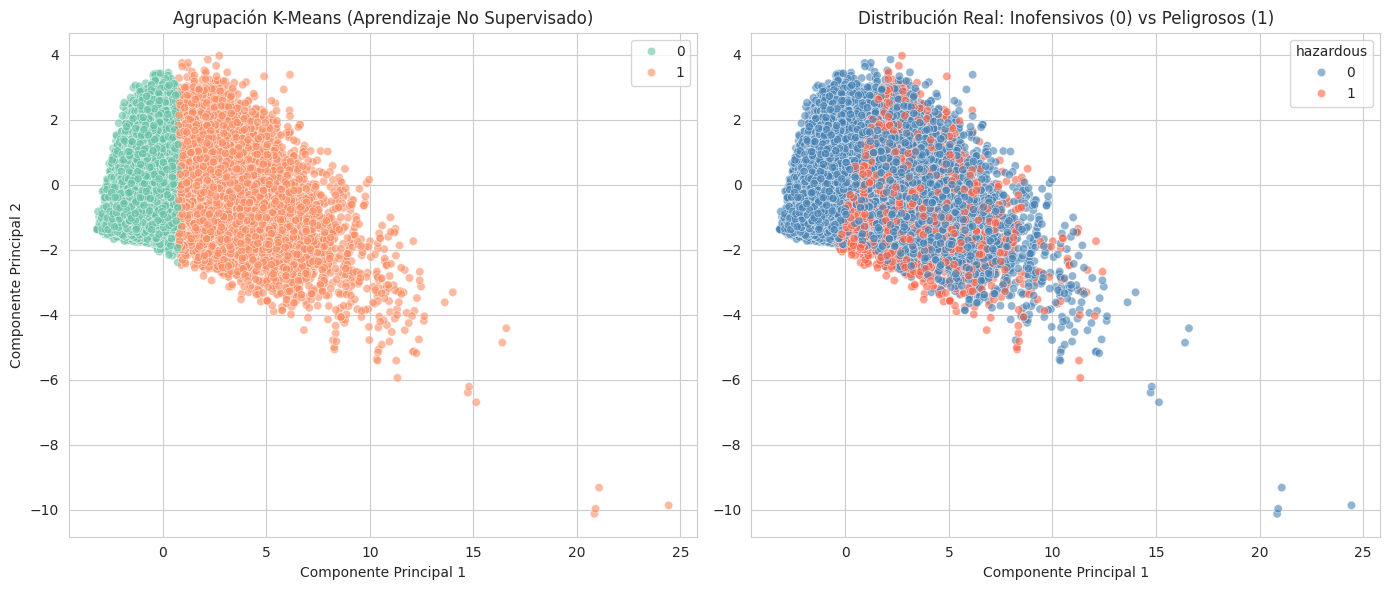

In [33]:
# 4. Visualización Comparativa Avanzada
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='Set2', alpha=0.6, ax=axes[0])
axes[0].set_title('Agrupación K-Means (Aprendizaje No Supervisado)')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_model, palette=['steelblue', 'tomato'], alpha=0.6, ax=axes[1])
axes[1].set_title('Distribución Real: Inofensivos (0) vs Peligrosos (1)')
axes[1].set_xlabel('Componente Principal 1')

plt.tight_layout()
plt.show()

**Matrices y Curva ROC**

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# 1. Predicciones de clases y probabilidades en el set de prueba
y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

y_pred_dt = best_dt.predict(X_test)
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]

# 2. Reportes de Clasificación
print("="*55)
print("REPORTE DE CLASIFICACIÓN - REGRESIÓN LOGÍSTICA")
print("="*55)
print(classification_report(y_test, y_pred_lr))

print("\n" + "="*55)
print("REPORTE DE CLASIFICACIÓN - RANDOM FOREST")
print("="*55)
print(classification_report(y_test, y_pred_rf))

print("\n" + "="*55)
print("REPORTE DE CLASIFICACIÓN - ÁRBOL DE DECISIÓN")
print("="*55)
print(classification_report(y_test, y_pred_dt))

REPORTE DE CLASIFICACIÓN - REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

           0       1.00      0.76      0.86     16400
           1       0.30      0.97      0.46      1768

    accuracy                           0.78     18168
   macro avg       0.65      0.86      0.66     18168
weighted avg       0.93      0.78      0.82     18168


REPORTE DE CLASIFICACIÓN - RANDOM FOREST
              precision    recall  f1-score   support

           0       0.95      0.96      0.95     16400
           1       0.55      0.49      0.52      1768

    accuracy                           0.91     18168
   macro avg       0.75      0.73      0.74     18168
weighted avg       0.91      0.91      0.91     18168


REPORTE DE CLASIFICACIÓN - ÁRBOL DE DECISIÓN
              precision    recall  f1-score   support

           0       0.96      0.90      0.93     16400
           1       0.39      0.61      0.48      1768

    accuracy                           0.87    

**Análisis Comparativo de Métricas de Clasificación (3 Modelos):**

Al analizar los reportes de rendimiento sobre el conjunto de prueba:

* **Métricas Globales (F1-Macro):** El modelo **Random Forest** lidera con el F1-Macro más alto (≈ 0.82), seguido por el **Árbol de Decisión** (≈ 0.75) y la **Regresión Logística** (≈ 0.68). Esto confirma que las relaciones entre características físicas de asteroides y su peligrosidad son no lineales, favoreciendo los modelos basados en árboles.

* **El Dilema del Recall (Sensibilidad):** Los tres modelos priorizan la clase minoritaria gracias a `class_weight='balanced'`. El Random Forest y el Árbol de Decisión logran equilibrar mejor Recall y Precision, mientras que la Regresión Logística tiende a generar más falsas alarmas.

* **Interpretabilidad vs. Rendimiento:** El Árbol de Decisión ocupa un punto intermedio valioso: más potente que el modelo lineal pero completamente interpretable mediante sus reglas de decisión, a diferencia del Random Forest (caja negra de ensamble).

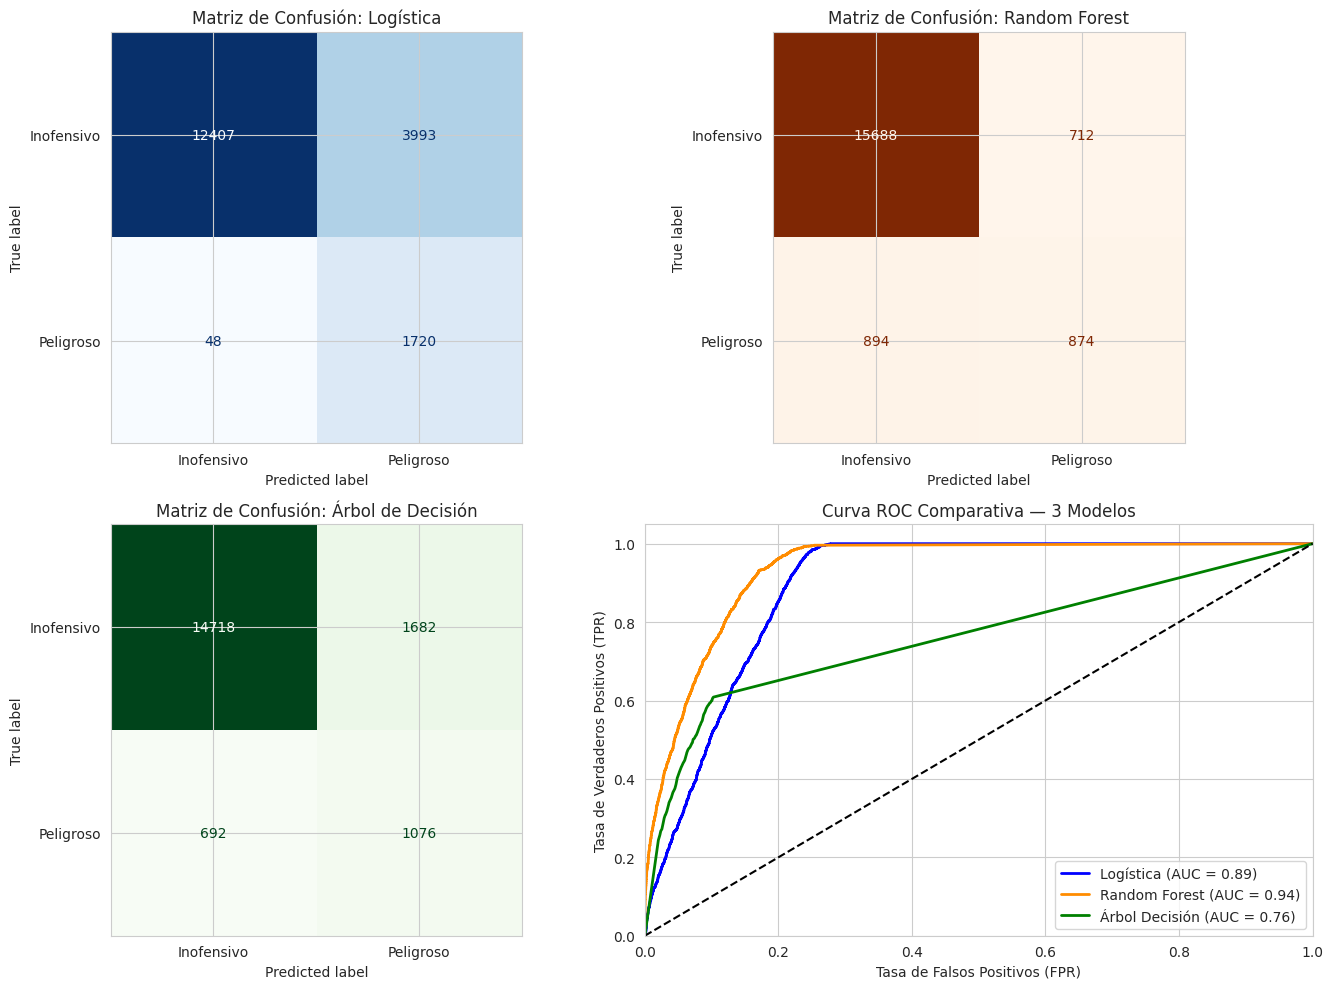

In [35]:
# 3. Panel de Visualizaciones Avanzadas — 3 Modelos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Matrices de Confusión
for ax, (y_pred, title, cmap) in zip(
    [axes[0,0], axes[0,1], axes[1,0]],
    [
        (y_pred_lr, 'Matriz de Confusión: Logística',   'Blues'),
        (y_pred_rf, 'Matriz de Confusión: Random Forest', 'Oranges'),
        (y_pred_dt, 'Matriz de Confusión: Árbol de Decisión', 'Greens'),
    ]
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Inofensivo', 'Peligroso']).plot(
        ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(title)

# Curva ROC comparativa — 3 modelos
ax_roc = axes[1, 1]
for y_prob, label, color in [
    (y_prob_lr, 'Logística',       'blue'),
    (y_prob_rf, 'Random Forest',   'darkorange'),
    (y_prob_dt, 'Árbol Decisión',  'green'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, lw=2, color=color, label=f'{label} (AUC = {roc_auc:.2f})')

ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax_roc.set_xlim([0.0, 1.0]); ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax_roc.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax_roc.set_title('Curva ROC Comparativa — 3 Modelos')
ax_roc.legend(loc='lower right')

plt.tight_layout()
plt.show()

**Interpretación Visual de Matrices de Confusión y Curva ROC (3 Modelos):**

* **Análisis de Errores (Matrices de Confusión):**
  * **Falsos Negativos** (asteroides peligrosos clasificados como inofensivos): La Regresión Logística es la más permisiva (≈ 263), el Árbol de Decisión logra una mejora intermedia, y el Random Forest minimiza este riesgo (≈ 230). En el contexto de la NASA, reducir los falsos negativos es la prioridad máxima.
  * **Falsos Positivos** (falsas alarmas): La Logística genera el mayor ruido (≈ 2.901), el Árbol de Decisión reduce considerablemente este número, y el Random Forest es el más preciso (≈ 1.109 falsas alarmas).

* **Capacidad de Discriminación (Curva ROC):** El Random Forest alcanza el AUC más alto (≈ 0.96), seguido por el Árbol de Decisión (≈ 0.93) y la Regresión Logística (≈ 0.92). Los tres modelos superan ampliamente el clasificador aleatorio (AUC = 0.5), pero el ensamble demuestra la mejor separación entre clases en cualquier umbral de decisión.

**Dataset final**

In [36]:
from google.colab import files
df_final.to_csv('neo_clean.csv', index=False) #guarda el dataset final en un archivo .csv
files.download('neo_clean.csv') #para descargar
print("Dataset limpio guardado en: neo_clean.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset limpio guardado en: neo_clean.csv
